In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

df = pd.read_csv("../data/processed/clean_sales.csv")
print(df.shape)
df.head()

(899, 12)


,Brands,Models,Colors,Memory,Storage,Camera,Rating,Selling Price,Original Price,Mobile,Discount,discount percentage
0,Samsung,Galaxy M31S,Mirage Black,8192.0,131072.0,True,4.3,19330,20999,SAMSUNG GALAXY M31S,1669,7.947998
1,Nokia,3.2,Steel,2048.0,16384.0,True,3.8,10199,10199,Nokia 3.2,0,0.000000
2,Realme,C2,Diamond Black,2048.0,0.0,True,4.4,6999,7999,realme C2,1000,12.501563
3,Infinix,Note 5,Ice Blue,4096.0,65536.0,True,4.2,12999,12999,Infinix Note 5,0,0.000000
4,Apple,Iphone 11,Black,4096.0,65536.0,True,4.6,49900,49900,Apple iPhone 11,0,0.000000


## Gráfico 1 — Distribución del Rating
¿Cómo se distribuyen las valoraciones de los usuarios tras la limpieza?

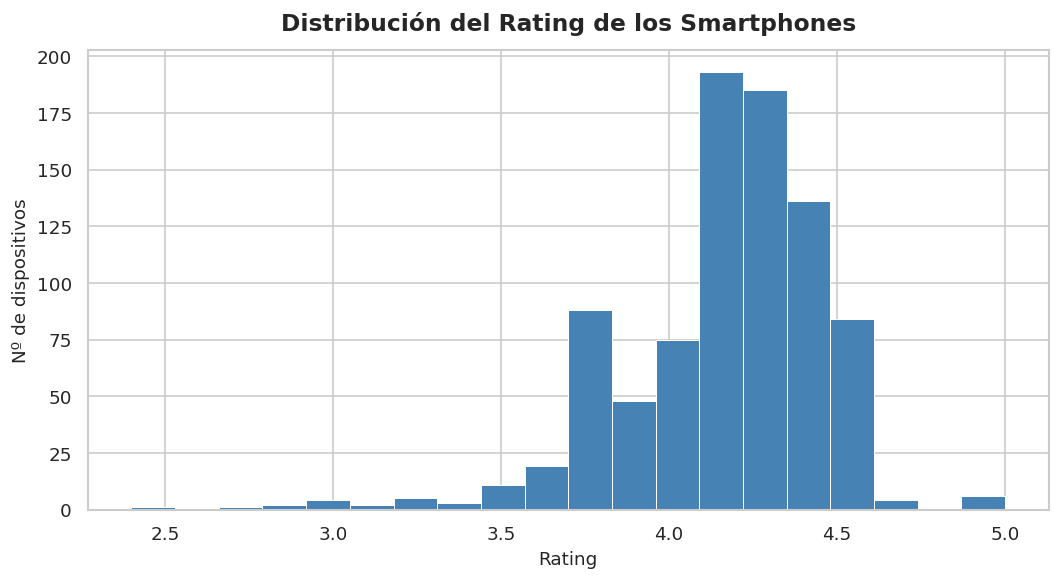

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

ratings = df[df['Rating'] > 0]['Rating']

ax.hist(ratings, bins=20, color='steelblue', edgecolor='white', linewidth=0.6)

ax.set_title('Distribución del Rating de los Smartphones', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Rating', fontsize=11)
ax.set_ylabel('Nº de dispositivos', fontsize=11)

plt.tight_layout()
plt.show()

### Conclusión
La distribución del rating está claramente sesgada hacia valores altos, concentrándose la mayoría de dispositivos entre **4.0 y 4.5**. Esto indica que los smartphones bien valorados son lo más usual en el dataset, y los móbiles con valoración inferior a 3.5 son casos más raros.

## Gráfico 2 — Modelos únicos por marca (En respuesta a Q4 del README)
¿Qué marca acumula más variedad de modelos únicos?

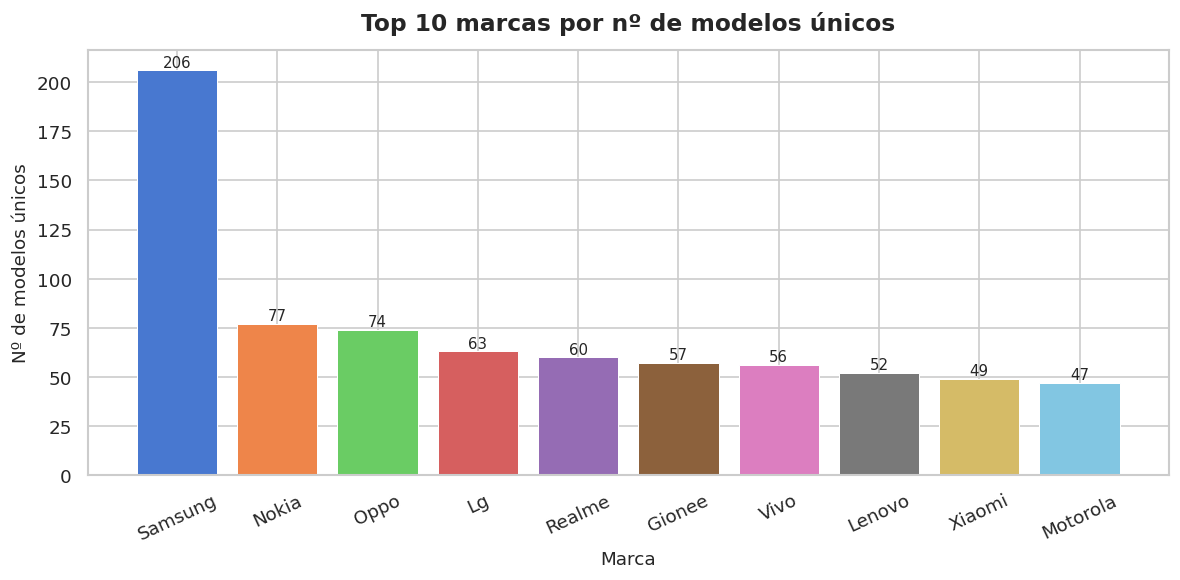

In [6]:
modelos_por_marca = (
    df.groupby('Brands')['Models']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(modelos_por_marca.index, modelos_por_marca.values,
              color=sns.color_palette('muted', len(modelos_por_marca)),
              edgecolor='white', linewidth=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
    
ax.set_title('Top 10 marcas por nº de modelos únicos', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Marca', fontsize=11)
ax.set_ylabel('Nº de modelos únicos', fontsize=11)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

### Conclusión
**SAMSUNG** lidera con diferencia en variedad de catálogo, seguida de **Nokia** y **Oppo**. Esto refleja la estrategia de estas marcas de cubrir todos los segmentos de precio con múltiples modelos, frente a marcas como Apple que apuestan por un catálogo más reducido y selectivo.

## Gráfico 3 — Distribución de precios por marca (Q5)
¿Cómo se distribuyen los precios de venta entre las distintas marcas?

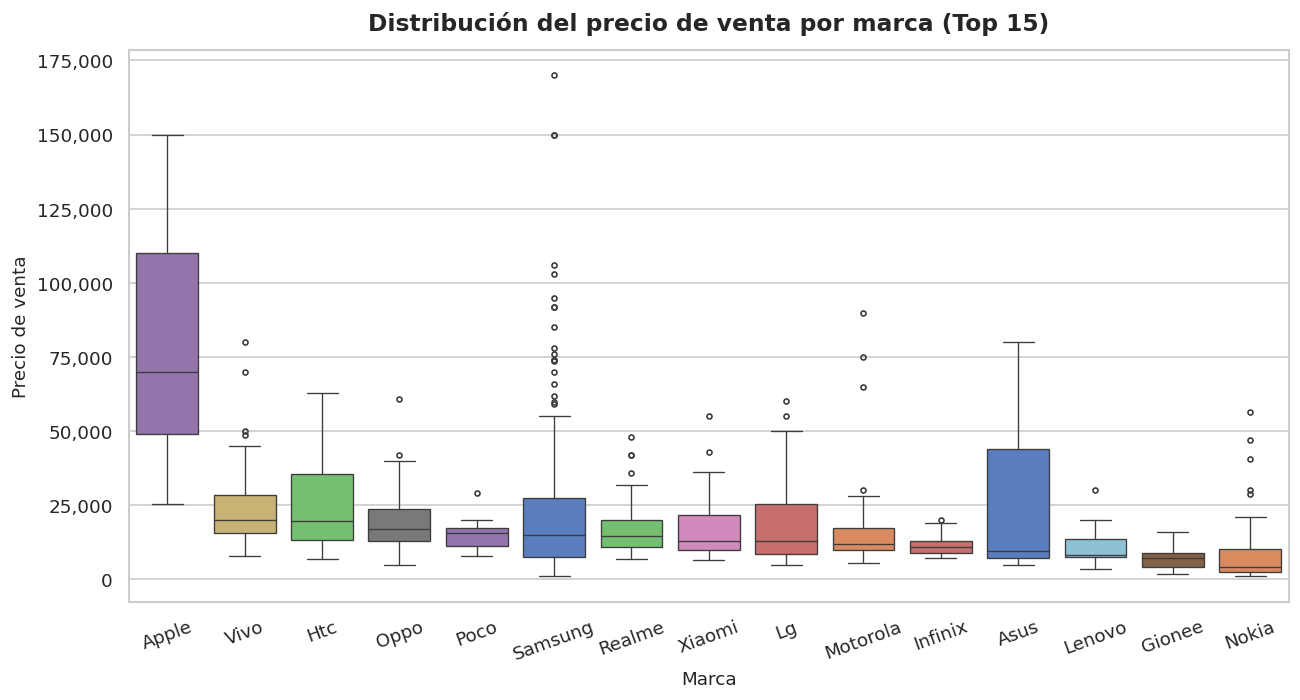

In [16]:
top_marcas = df['Brands'].value_counts().head(15).index
df_top = df[df['Brands'].isin(top_marcas) & (df['Selling Price'] > 0)]

orden = (
    df_top.groupby('Brands')['Selling Price']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(data=df_top, x='Brands', y='Selling Price', order=orden,
            hue='Brands', legend=False,
            palette='muted', linewidth=0.8, fliersize=3, ax=ax)

ax.set_title('Distribución del precio de venta por marca (Top 15)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Marca', fontsize=11)
ax.set_ylabel('Precio de venta', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Conclusión
**Apple** presenta la mediana de precio más alta y la dispersión más elevada, lo que refleja que efectivamente se posiciona en gama alta. Marcas como **realme** o **Xiaomi** muestran precios más bajos y concentrados, lo que va acorde a su estrategia de gama media-baja. **SAMSUNG** destaca por tener la mayor dispersión después de Apple, cubriendo desde gama baja hasta alta.

## Gráfico 4 — Precio de venta vs Rating (Q6)
¿Existe relación visible entre el precio de venta y el rating de los usuarios?

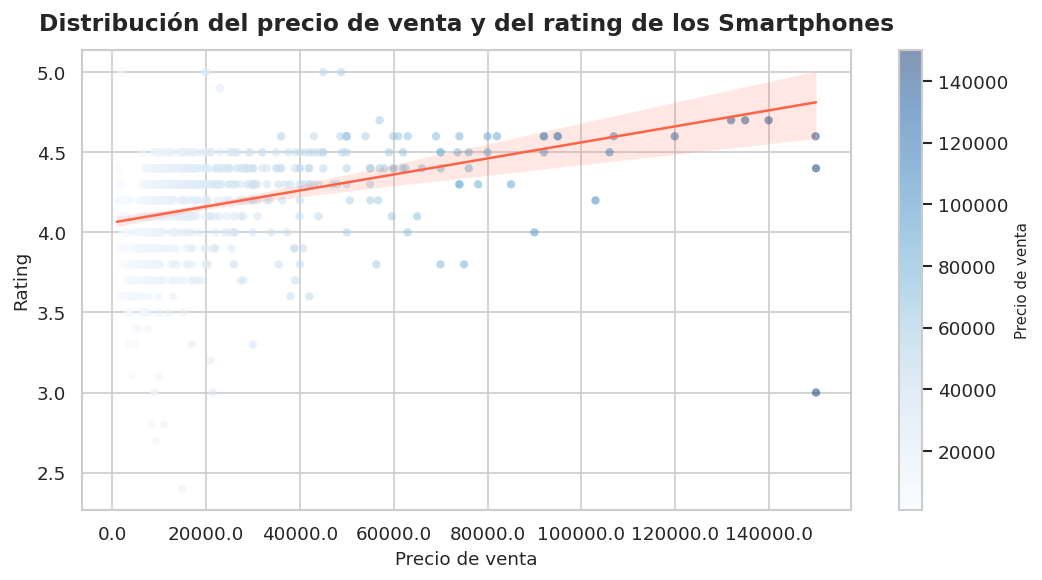

In [17]:
df_scatter = df[(df['Selling Price'] > 0) & (df['Rating'] > 0)]

fig, ax = plt.subplots(figsize=(9, 5))

scatter = ax.scatter(
    df_scatter['Selling Price'],
    df_scatter['Rating'],
    alpha=0.5, s=25,
    c=df_scatter['Selling Price'],
    cmap='Blues',
    edgecolor='none'
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Precio de venta', fontsize=9)

sns.regplot(data=df_scatter, x='Selling Price', y='Rating', scatter=False, color='tomato', line_kws={'linewidth': 1.5, 'label': 'Tendencia'}, ax=ax)

ax.set_title('Distribución del precio de venta y del rating de los Smartphones', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Precio de venta', fontsize=11)
ax.set_ylabel('Rating', fontsize=11)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}'))

plt.tight_layout()
plt.show()

### Conclusión
La línea de tendencia muestra una **correlación positiva débil** entre el precio y el rating: los dispositivos más caros tienden a tener valoraciones ligeramente superiores, pero eso no es determinante. Hay dispositivos de precio bajo con ratings altos, lo que sugiere que el precio no es el único factor que determina la satisfacción del usuario.

## Gráfico 5 — Descuento medio por marca
¿Qué marcas aplican mayores descuentos en media?

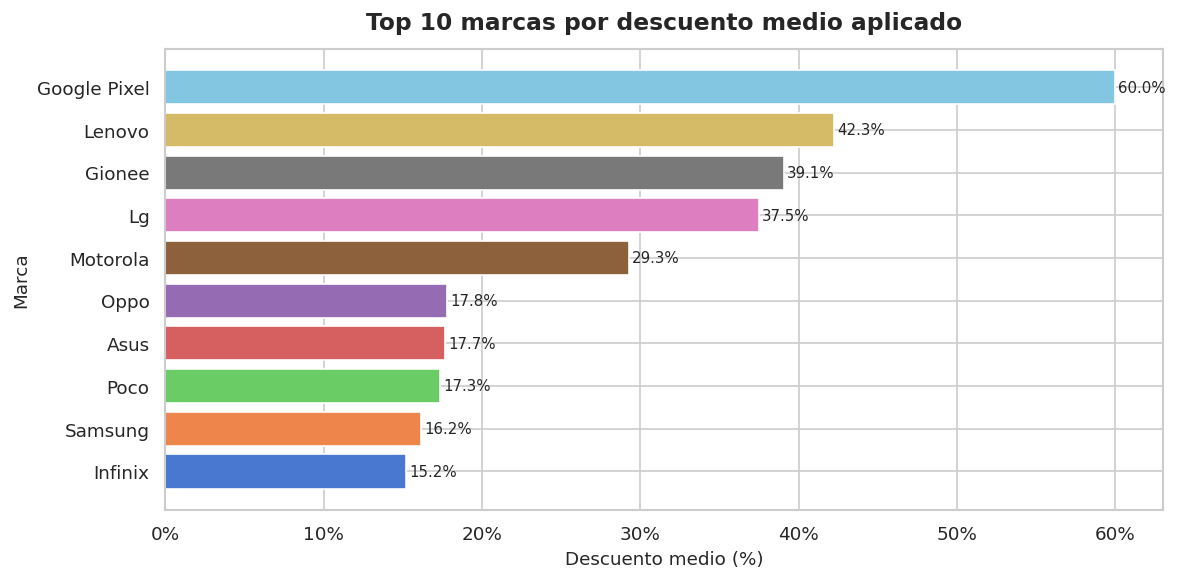

In [18]:
descuento_medio = (
    df[df['discount percentage'] > 0]
    .groupby('Brands')['discount percentage']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(descuento_medio.index[::-1], descuento_medio.values[::-1],
               color=sns.color_palette('muted', len(descuento_medio)),
               edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)

ax.set_title('Top 10 marcas por descuento medio aplicado', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Descuento medio (%)', fontsize=11)
ax.set_ylabel('Marca', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

### Conclusión
Aquí queda claro que las marcas con mayores descuentos de media no siempre son las más conocidas, lo que puede indicar estrategias de liquidación de stock o mayor presión competitiva en ciertos segmentos. Un descuento elevado sostenido puede ser señal de que el precio original era más elevado de lo que debería respecto al mercado.

## Gráfico 6 — Rating medio por marca
¿Qué marcas tienen mejor valoración media entre sus dispositivos?

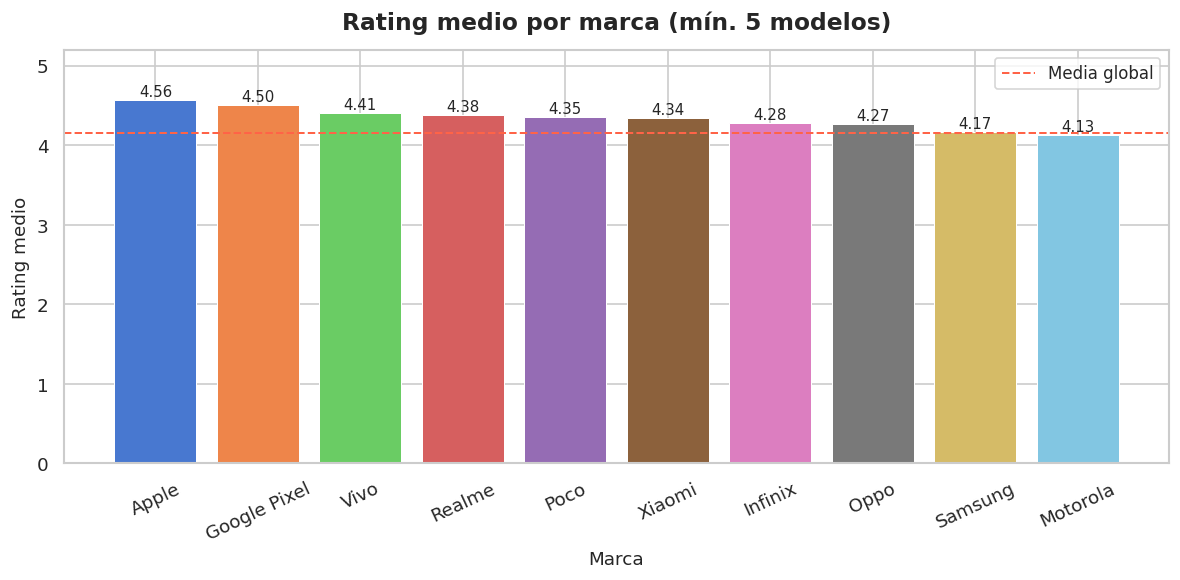

In [19]:
rating_medio = (
    df[df['Rating'] > 0]
    .groupby('Brands')['Rating']
    .agg(['mean', 'count'])
    .query('count >= 5')
    .sort_values('mean', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(rating_medio.index, rating_medio['mean'],
              color=sns.color_palette('muted', len(rating_medio)),
              edgecolor='white', linewidth=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Rating medio por marca (mín. 5 modelos)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Marca', fontsize=11)
ax.set_ylabel('Rating medio', fontsize=11)
ax.set_ylim(0, 5.2)
ax.axhline(df[df['Rating'] > 0]['Rating'].mean(), color='tomato',
           linestyle='--', linewidth=1.2, label='Media global')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

### Conclusión
Filtrando marcas con al menos 5 modelos para que la media sea representativa, se observa que las diferencias entre marcas son pequeñas pero consistentes. Las marcas por encima de la media global tienen en común un catálogo orientado a gama media-alta, mientras que las que quedan por debajo tienden a competir principalmente en precio.